# 02 - Treinamento ResNet-50

Fine-tuning da ResNet-50 pré-treinada no ImageNet para classificação binária de rostos reais vs gerados por IA.

1. Carregamento dos dados
2. Definição do modelo
3. Treinamento com early stopping
4. Curvas de loss e acurácia
5. Avaliação no conjunto de teste
6. Matriz de confusão e curva ROC

In [1]:
import copy
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

In [2]:
import json

PROJECT_ROOT    = Path.cwd().resolve().parent
_data_root_file = PROJECT_ROOT / "data_root.env"
DATA_ROOT       = Path(_data_root_file.read_text().strip()) if _data_root_file.exists() else PROJECT_ROOT / "data"
COMPRESSED_DIR  = DATA_ROOT / "processed" / "140k_faces_compressed"
DATASET_DIR     = DATA_ROOT / "raw" / "140k_faces"
DATA_PATH       = COMPRESSED_DIR if COMPRESSED_DIR.exists() else DATASET_DIR / "real_vs_fake" / "real-vs-fake"
MODEL_DIR       = PROJECT_ROOT / "artifacts" / "models"
FIGURES_DIR     = PROJECT_ROOT / "reports" / "figures"

# detecta qualidade de compressão para nomear arquivos
_meta = COMPRESSED_DIR / "metadata.json"
COMPRESSION_TAG = f"q{json.load(open(_meta))['jpeg_quality']}" if _meta.exists() else "raw"
MODEL_PATH      = MODEL_DIR / f"resnet50_{COMPRESSION_TAG}.pth"

IMAGE_SIZE    = 224
BATCH_SIZE    = 32
NUM_WORKERS   = 4
NUM_EPOCHS    = 20
LEARNING_RATE = 1e-4
PATIENCE      = 5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for folder in [MODEL_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
print("Dataset:", DATA_PATH)
print("Tag:", COMPRESSION_TAG)

Device: cuda
Dataset: C:\Users\pedro\data_projeto5\processed\140k_faces_compressed
Tag: q50


## 1. Dados

In [3]:
import torch
from torch.utils.data import Subset
import random

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
SAMPLE_FRACTION = 0.2  # 1.0 para usar tudo

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def sample_dataset(dataset, fraction, seed=42):
    n = int(len(dataset) * fraction)
    indices = random.Random(seed).sample(range(len(dataset)), n)
    return Subset(dataset, indices)

train_dataset = sample_dataset(datasets.ImageFolder(DATA_PATH / "train", transform=train_transform), SAMPLE_FRACTION)
valid_dataset = sample_dataset(datasets.ImageFolder(DATA_PATH / "valid", transform=eval_transform), SAMPLE_FRACTION)
test_dataset  = sample_dataset(datasets.ImageFolder(DATA_PATH / "test",  transform=eval_transform), SAMPLE_FRACTION)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

CLASSES = train_dataset.dataset.classes
print("Classes:", CLASSES)
print(f"Treino:    {len(train_dataset):>6} | Validacao: {len(valid_dataset):>6} | Teste: {len(test_dataset):>6}")

Classes: ['fake', 'real']
Treino:     20000 | Validacao:   4000 | Teste:   4000


## 2. Modelo

ResNet-50 pré-treinada no ImageNet. A camada final (`fc`) é substituída por um classificador binário com dropout.

In [4]:
def build_resnet50(num_classes=2, dropout=0.5):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes)
    )
    return model

model = build_resnet50().to(DEVICE)
print("Modelo carregado. Camada final:", model.fc)

Modelo carregado. Camada final: Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=2048, out_features=2, bias=True)
)


## 3. Treinamento

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=2, factor=0.5)

history = {"train_loss": [], "train_acc": [], "valid_loss": [], "valid_acc": [], "time": []}
best_val_loss = float("inf")
best_weights = None
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    start = time.time()

    model.train()
    train_loss, train_correct = 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    model.eval()
    valid_loss, valid_correct = 0.0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            valid_loss += loss.item() * images.size(0)
            valid_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss /= len(train_dataset)
    train_acc   = train_correct / len(train_dataset)
    valid_loss /= len(valid_dataset)
    valid_acc   = valid_correct / len(valid_dataset)
    elapsed     = time.time() - start

    history["train_loss"].append(round(train_loss, 6))
    history["train_acc"].append(round(train_acc, 6))
    history["valid_loss"].append(round(valid_loss, 6))
    history["valid_acc"].append(round(valid_acc, 6))
    history["time"].append(round(elapsed, 1))

    scheduler.step(valid_loss)

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {valid_loss:.4f} Acc: {valid_acc:.4f} | "
          f"{elapsed:.1f}s", flush=True)

    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        best_weights = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping na epoch {epoch+1}.", flush=True)
            break

model.load_state_dict(best_weights)
torch.save(best_weights, MODEL_PATH)

history_out = MODEL_DIR / f"resnet50_history_{COMPRESSION_TAG}.json"
with open(history_out, "w") as f:
    json.dump({"model": "resnet50", "compression": COMPRESSION_TAG, "epochs": [
        {"epoch": i+1, "train_loss": history["train_loss"][i], "train_acc": history["train_acc"][i],
         "val_loss": history["valid_loss"][i], "val_acc": history["valid_acc"][i], "time": history["time"][i]}
        for i in range(len(history["train_loss"]))
    ]}, f, indent=2)

print("Modelo salvo em:", MODEL_PATH)
print("Histórico salvo em:", history_out)

Epoch 01/20 | Train Loss: 0.3167 Acc: 0.8613 | Val Loss: 0.2102 Acc: 0.9042 | 180.5s
Epoch 02/20 | Train Loss: 0.1325 Acc: 0.9497 | Val Loss: 0.1107 Acc: 0.9590 | 176.0s
Epoch 03/20 | Train Loss: 0.0855 Acc: 0.9684 | Val Loss: 0.0875 Acc: 0.9702 | 183.7s
Epoch 04/20 | Train Loss: 0.0613 Acc: 0.9779 | Val Loss: 0.1203 Acc: 0.9617 | 183.9s
Epoch 05/20 | Train Loss: 0.0469 Acc: 0.9832 | Val Loss: 0.0768 Acc: 0.9708 | 179.8s
Epoch 06/20 | Train Loss: 0.0423 Acc: 0.9853 | Val Loss: 0.0771 Acc: 0.9745 | 178.7s
Epoch 07/20 | Train Loss: 0.0371 Acc: 0.9866 | Val Loss: 0.0856 Acc: 0.9708 | 178.1s
Epoch 08/20 | Train Loss: 0.0351 Acc: 0.9869 | Val Loss: 0.0752 Acc: 0.9745 | 177.5s
Epoch 09/20 | Train Loss: 0.0295 Acc: 0.9891 | Val Loss: 0.0631 Acc: 0.9758 | 176.8s
Epoch 10/20 | Train Loss: 0.0251 Acc: 0.9908 | Val Loss: 0.0635 Acc: 0.9788 | 176.7s
Epoch 11/20 | Train Loss: 0.0238 Acc: 0.9912 | Val Loss: 0.0504 Acc: 0.9825 | 177.8s
Epoch 12/20 | Train Loss: 0.0232 Acc: 0.9920 | Val Loss: 0.0905 A

## 4. Curvas de Treinamento

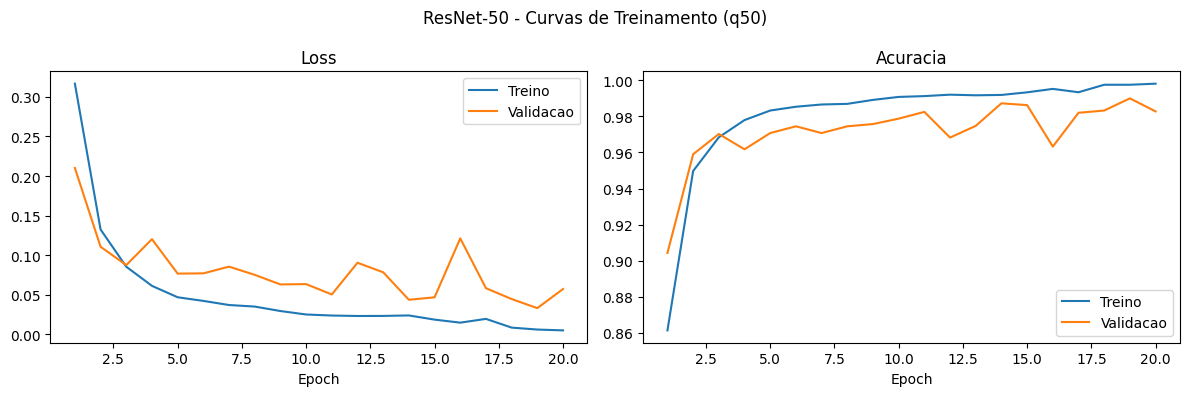

In [6]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, history["train_loss"], label="Treino")
ax1.plot(epochs_range, history["valid_loss"], label="Validacao")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(epochs_range, history["train_acc"], label="Treino")
ax2.plot(epochs_range, history["valid_acc"], label="Validacao")
ax2.set_title("Acuracia")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.suptitle(f"ResNet-50 - Curvas de Treinamento ({COMPRESSION_TAG})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"resnet50_training_curves_{COMPRESSION_TAG}.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Avaliação no Teste

In [7]:
model.eval()
all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        preds = outputs.argmax(1).cpu().numpy()
        all_labels.extend(labels.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

report = classification_report(all_labels, all_preds, target_names=CLASSES, output_dict=True)
auc = round(roc_auc_score(all_labels, all_probs), 6)

print(classification_report(all_labels, all_preds, target_names=CLASSES))
print("AUC-ROC:", auc)

metrics_out = MODEL_DIR / f"resnet50_metrics_{COMPRESSION_TAG}.json"
with open(metrics_out, "w") as f:
    json.dump({"model": "resnet50", "compression": COMPRESSION_TAG, "auc_roc": auc, "report": report}, f, indent=2)
print("Métricas salvas em:", metrics_out)

              precision    recall  f1-score   support

        fake       0.99      0.99      0.99      1993
        real       0.99      0.99      0.99      2007

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000

AUC-ROC: 0.999604
Métricas salvas em: C:\Users\pedro\Projeto-5-Redes-Neurais\artifacts\models\resnet50_metrics_q50.json


## 6. Matriz de Confusão e Curva ROC

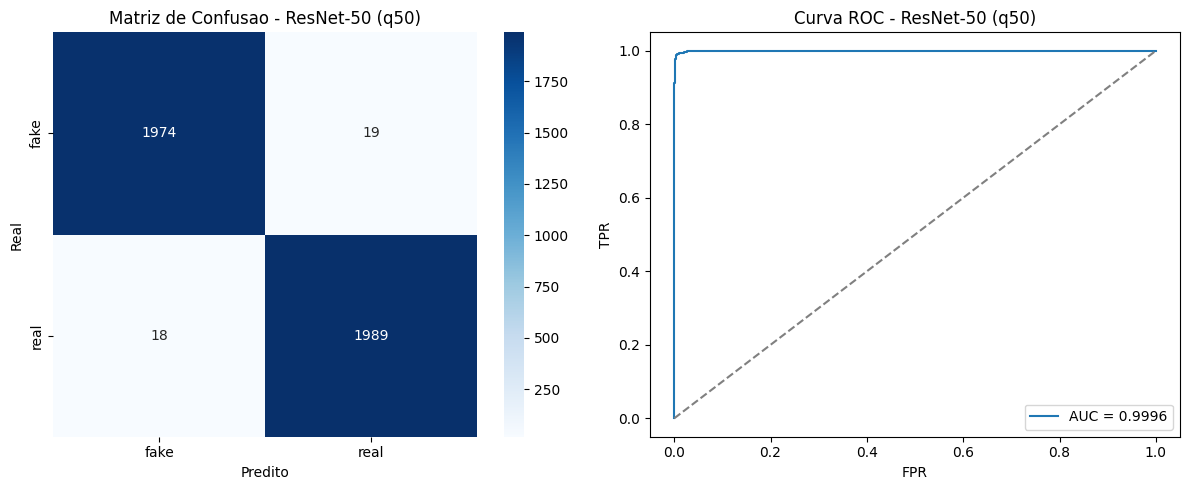

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax1)
ax1.set_title(f"Matriz de Confusao - ResNet-50 ({COMPRESSION_TAG})")
ax1.set_ylabel("Real")
ax1.set_xlabel("Predito")

fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc = roc_auc_score(all_labels, all_probs)
ax2.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
ax2.plot([0, 1], [0, 1], "--", color="gray")
ax2.set_title(f"Curva ROC - ResNet-50 ({COMPRESSION_TAG})")
ax2.set_xlabel("FPR")
ax2.set_ylabel("TPR")
ax2.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"resnet50_confusion_roc_{COMPRESSION_TAG}.png", dpi=150, bbox_inches="tight")
plt.show()